In [11]:
from dotenv import load_dotenv
import os

load_dotenv()

db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")
print(db_host)
print(db_port)
print(db_name)
print(db_user)
# print(api_key is not None)
# api_key = os.getenv("API_KEY")

localhost
5432
economic_analysis
postgres


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

# 🔌 DATABASE CONNECTION
DB_HOST=os.getenv("DB_HOST")
DB_PORT=os.getenv("DB_PORT")
DB_NAME=os.getenv("DB_NAME")
DB_USER=os.getenv("DB_USER")
DB_PASSWORD=os.getenv("DB_PASSWORD")


engine_temp = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/postgres"
)

with engine_temp.connect() as conn:
    conn.execute(text("COMMIT"))
    try:
        conn.execute(text(f"CREATE DATABASE {DB_NAME}"))
        print("Database created")
    except Exception:
        print("Database already exists")
        
engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Connected to database")

#CLEAN FUNCTION

def clean_columns(df):
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace(r"\(.*?\)", "", regex=True)
    )
    return df


#table creation

def create_tables():
    with engine.connect() as conn:

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS agriculture_production (
            id SERIAL PRIMARY KEY,
            crop_id INT,
            crop TEXT,
            crop_type TEXT,
            year INT,
            indicator TEXT,
            value FLOAT
        );
        """))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS livestock_production (
            id SERIAL PRIMARY KEY,
            year INT,
            category TEXT,
            main_category TEXT,
            production FLOAT,
            growth_rate FLOAT
        );
        """))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS cpi_data (
            id SERIAL PRIMARY KEY,
            date DATE,
            fiscal_year TEXT,
            year INT,
            category TEXT,
            value FLOAT
        );
        """))

        conn.execute(text("""
        CREATE TABLE IF NOT EXISTS gdp_data (
            id SERIAL PRIMARY KEY,
            sector TEXT,
            year INT,
            quarter TEXT,
            value FLOAT
        );
        """))

    print("Tables ready")



# AGRICULTURE ETL
def process_agriculture():

    cash = clean_columns(pd.read_csv("cleanedData/clean_cashCrops.csv"))
    food = clean_columns(pd.read_csv("cleanedData/clean_foodCrops.csv"))

    cash["crop_type"] = "cash"
    food["crop_type"] = "food"

    df = pd.concat([cash, food], ignore_index=True)

    df = df.drop(columns=["unnamed:_0"], errors="ignore")

    df["crop"] = df["crop"].astype(str).str.lower().str.strip()
    df["crop_type"] = df["crop_type"].astype(str).str.lower().str.strip()

    df["year"] = pd.to_datetime(df["year"], errors="coerce").dt.year

    # FIX: unify value column
    df["value"] = df["value"].astype(float)

    # crop_id (NO MERGE)
    df["crop_id"] = pd.factorize(df["crop"] + "_" + df["crop_type"])[0] + 1

    final = df[[
        "crop_id", "crop", "crop_type",
        "year", "type", "value"
    ]].drop_duplicates()

    final.to_sql("agriculture_production", engine, if_exists="append", index=False)

    print("Agriculture loaded")


# LIVESTOCK ETL

def process_livestock():

    df = clean_columns(pd.read_csv("cleanedData/liveStockProduction.csv"))

    df = df.drop_duplicates()

    df.to_sql("livestock_production", engine, if_exists="append", index=False)

    print("Livestock loaded")


# ==============================
# CPI ETL
# ==============================
def process_cpi():

    df = clean_columns(pd.read_csv("cleanedData/CleanedNational-cpi.csv"))

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["year"].astype(int)

    id_vars = ["date", "fiscal_year", "year"]

    long = df.melt(
        id_vars=id_vars,
        var_name="category",
        value_name="value"
    ).drop_duplicates()

    long.to_sql("cpi_data", engine, if_exists="append", index=False)

    print("CPI loaded")



# GDP ETL

def process_gdp():

    df = clean_columns(pd.read_csv("cleanedData/quarterly_gdp.csv"))

    df.to_sql("gdp_data", engine, if_exists="append", index=False)

    print("GDP loaded")


#  RUN ALL

def run_all():
    create_tables()
    process_agriculture()
    process_livestock()
    process_cpi()
    process_gdp()

    print("ALL ETL COMPLETED SUCCESSFULLY")


if __name__ == "__main__":
    run_all()

ValueError: invalid literal for int() with base 10: 'None'

In [8]:
#Q1. How has total agricultural production changed over time?
query = "SELECT * FROM agriculture_production"
df = pd.read_sql(query, engine)
data = df[df["type"]=="Production"]
data = df.groupby("year")["value"].sum().reset_index()

data1 = df[(df["type"]=="Productivity") & (df["year"]<2024)]
data2 = data1.groupby("year")["value"].sum().reset_index()

data4 = df[(df["type"]=="Area") & (df["year"]<2024)]
data3 = data4.groupby("year")["value"].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(x="year",y="value",data= data,marker="o",label="production")
sns.lineplot(x="year",y="value",data= data2,marker="o",label="productivity")
sns.lineplot(x="year",y="value",data= data3,marker="o",label="area")
plt.legend()
plt.show()

df
#insights: we can see that overall production is growing but in the initial year it is up and down
# we can see the pattern where production has been increased since area increases.
# the most important role is played by agruculture production area,when area increases production increases and vice-versa

NameError: name 'engine' is not defined

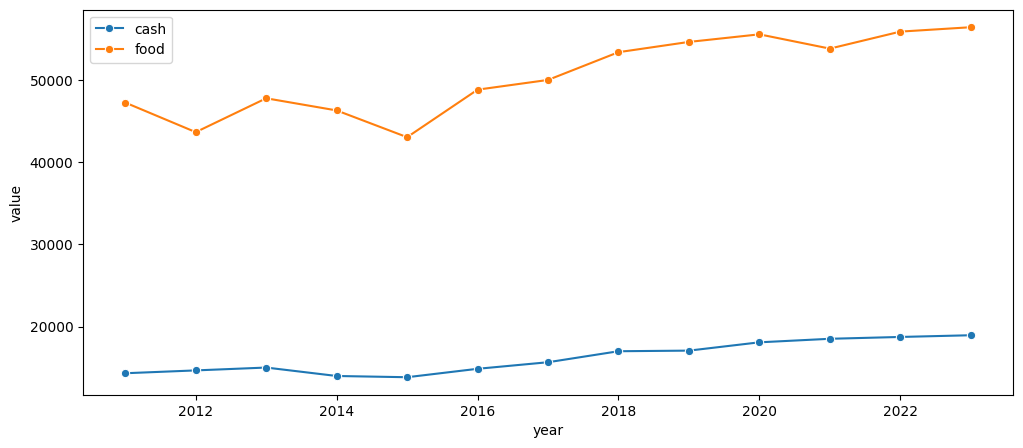

In [45]:
#Q2. How do food crops and cash crops production trends compare over time?
# so we need line plot of two numeric value comparision
query = "SELECT * FROM agriculture_production"
df = pd.read_sql(query, engine)
cash_cropData = df[(df["crop_type"]=="cash") & (df["type"]=="Production")]
cash_grouped_data = cash_cropData.groupby("year")["value"].sum().reset_index()
cash_grouped_data

food_cropData = df[(df["crop_type"]=="food") & (df["type"]=="Production")]
food_grouped_data = food_cropData.groupby("year")["value"].sum().reset_index()
food_grouped_data  

plt.figure(figsize=(12,5))
sns.lineplot(x="year",y="value",data= cash_grouped_data,marker="o",label="cash")
sns.lineplot(x="year",y="value",data= food_grouped_data,marker="o",label="food")
plt.legend()
plt.show()

#insights: food crops are more volatile then cash crops,it shows climate or other factors affect much.
#nepal is food-driven not market driven. the economy suggests missing export and income oppurtunities from high value crops

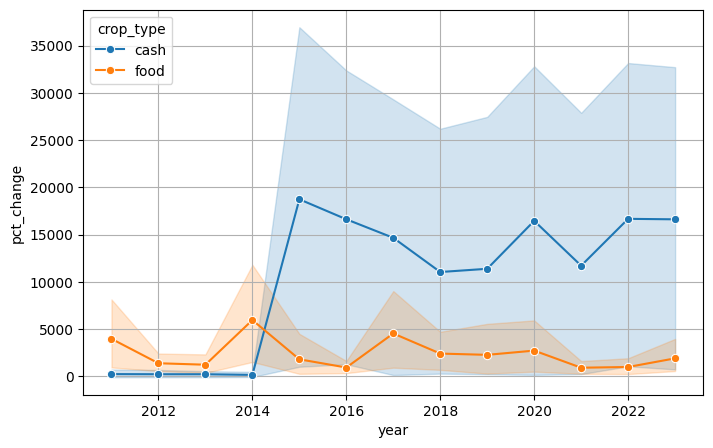

In [52]:
#Q3. Is the growth rate of cash crops higher than food crops over time?
query = """WITH data as (
SELECT 
    crop_type,
	type,
    year,
    value,
    LAG(value) OVER (PARTITION BY crop_type ORDER BY year) AS prev_value
FROM agriculture_production
where type = 'Production'
)
SELECT 
	*,
	(value-prev_value)/nullif(prev_value,0)*100 as pct_change
FROM data;
"""
data = pd.read_sql(query,engine)
plt.figure(figsize=(8,5))
sns.lineplot(x="year",y="pct_change",data=data,hue="crop_type",marker="o")
plt.grid()
plt.show()
#insights:there are signs of faster growth of cash crops but not structural shift toward commerical aggriculture

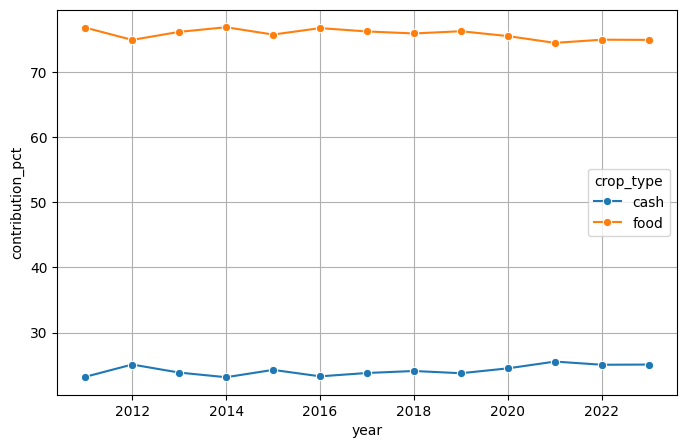

In [53]:
#Q4: Contribution to total agriculture
query = """SELECT 
    year,
    crop_type,
    SUM(value) * 100.0 / SUM(SUM(value)) OVER (PARTITION BY year) AS contribution_pct
FROM agriculture_production
WHERE type = 'Production'
GROUP BY year, crop_type;"""
data = pd.read_sql(query,engine)
plt.figure(figsize=(8,5))
sns.lineplot(x="year",y="contribution_pct",data=data,hue="crop_type",marker="o")
plt.grid()
plt.show()
#insights: food crops dominates and when food crops declines,the cash crops increase and vice-versa.it shows possible diversification
# substince-focused economy

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        13 non-null     int64  
 1   production  13 non-null     float64
 2   cpi_value   13 non-null     str    
dtypes: float64(1), int64(1), str(1)
memory usage: 444.0 bytes


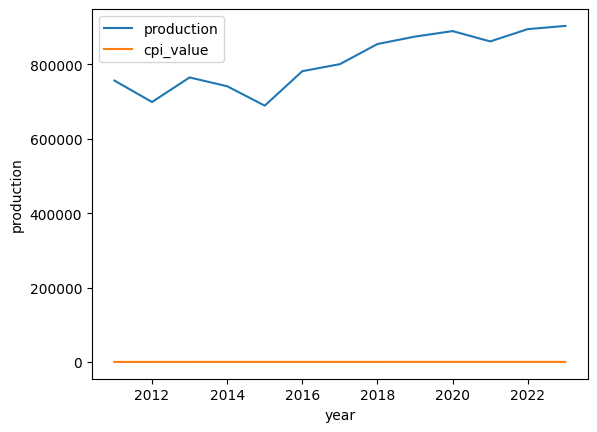

,prod_change,cpi_change
prod_change,1.000000,-0.498045
cpi_change,-0.498045,1.000000


In [68]:
#Do drops in food crop production correspond with increases in CPI (inflation)?
query = """SELECT 
    a.year,
    SUM(a.value) as production,
    c.value as cpi_value
FROM agriculture_production a
JOIN cpi_data c
ON c.year = a.year
WHERE a.crop_type = 'food' AND a.type='Production'
AND c.category = 'fiscal_year_food_and_beverages'
GROUP BY a.year,c.value
ORDER BY a.year
"""
data = pd.read_sql(query,engine)
# data["category"].unique()
data.info()
data["cpi_value"] = pd.to_numeric(data["cpi_value"])
data.isnull().sum()
sns.lineplot(x="year",y="production",data=data,label="production")
sns.lineplot(x="year",y="cpi_value",data=data,label="cpi_value")
plt.show()
data["prod_change"] = data["production"].pct_change()*100
data["cpi_change"] = data["cpi_value"].pct_change()*100
data[["prod_change","cpi_change"]].corr()

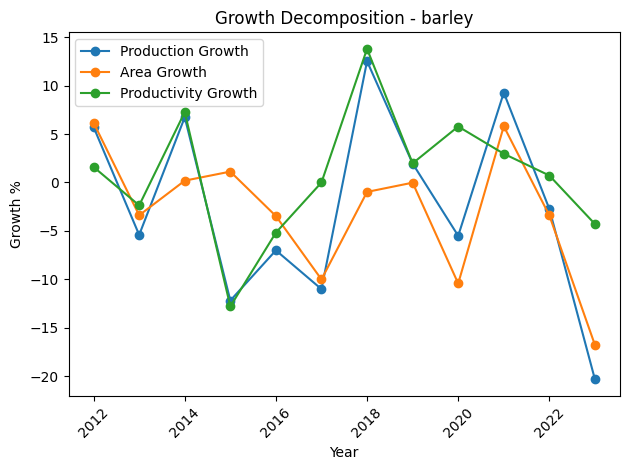

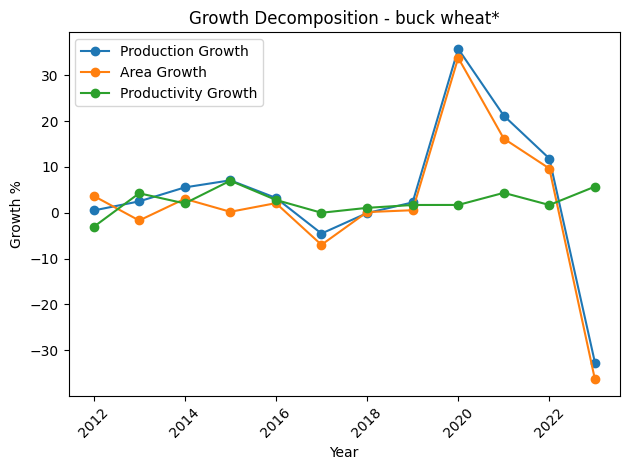

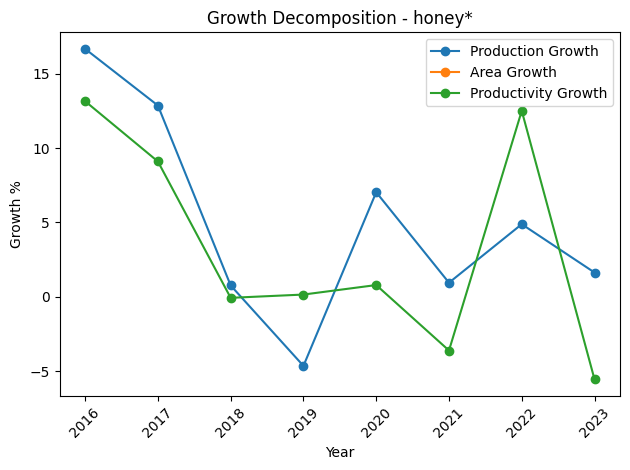

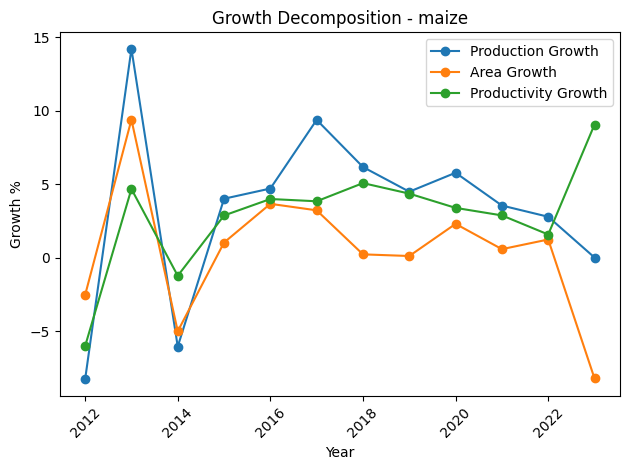

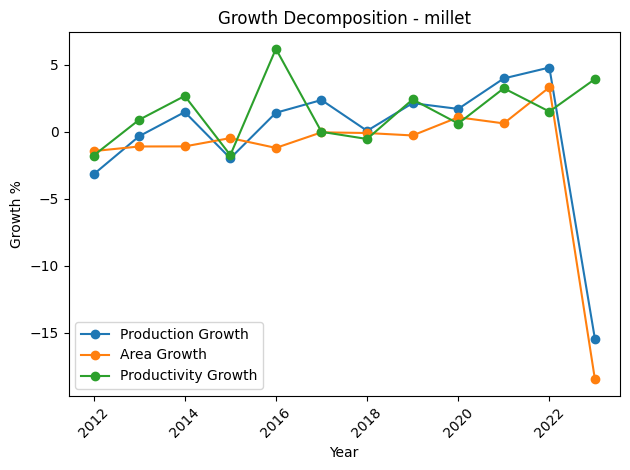

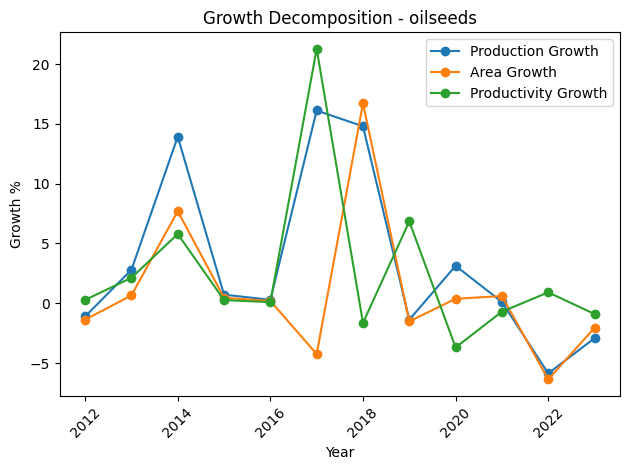

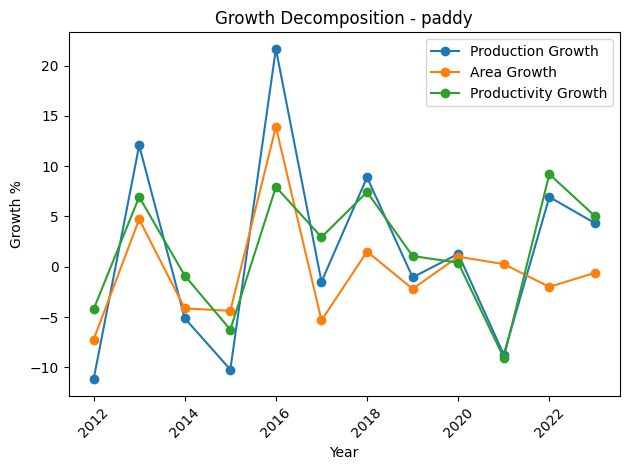

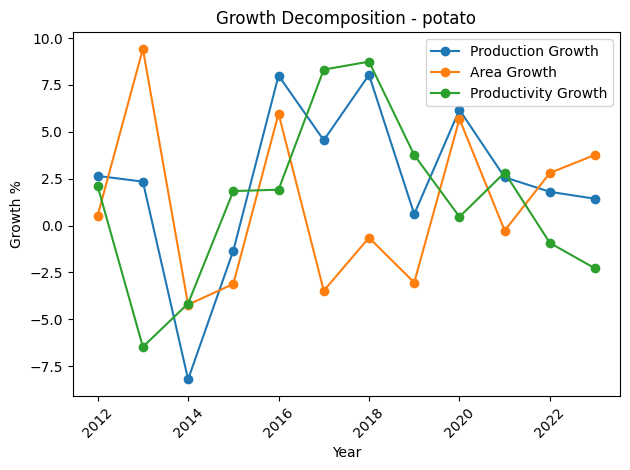

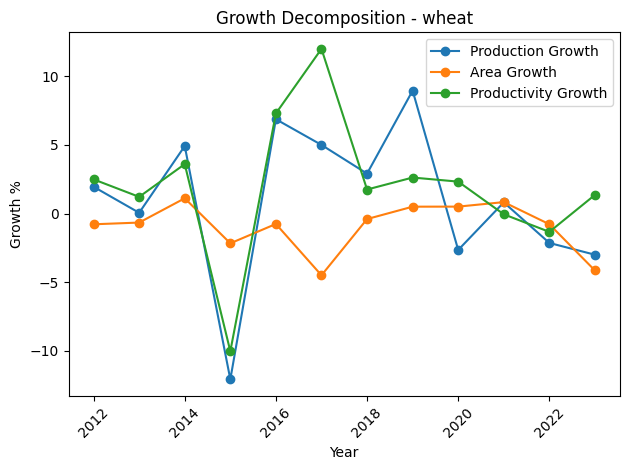

,prod_growth,area_growth,productivity_growth
prod_growth,1.000000,0.468895,0.525508
area_growth,0.468895,1.000000,-0.504116
productivity_growth,0.525508,-0.504116,1.000000


In [51]:
#Is productivity improving (output per land)?
query = """WITH base AS (
  SELECT
    crop,
    year,
    MAX(CASE WHEN type = 'Area' THEN value END) AS area,
    MAX(CASE WHEN type = 'Production' THEN value END) AS production,
    MAX(CASE WHEN type = 'Productivity' THEN value END) AS productivity
  FROM agriculture_production
  GROUP BY crop, year
),
calc AS (
  SELECT
    crop,
    year,
    production,
    area,
    productivity,
    LAG(production) OVER (PARTITION BY crop ORDER BY year) AS prev_prod,
    LAG(area) OVER (PARTITION BY crop ORDER BY year) AS prev_area,
    LAG(productivity) OVER (PARTITION BY crop ORDER BY year) AS prev_prodty
  FROM base
)
SELECT
  crop,
  year,
  (production - prev_prod) / NULLIF(prev_prod, 0) * 100 AS prod_growth,
  (area - prev_area) / NULLIF(prev_area, 0) * 100 AS area_growth,
  (productivity - prev_prodty) / NULLIF(prev_prodty, 0) * 100 AS productivity_growth
FROM calc
ORDER BY crop, year;
"""
data = pd.read_sql(query,engine)
for crop in data['crop'].unique():
    subset = data[data['crop'] == crop]
    
    plt.figure()
    
    plt.plot(subset['year'], subset['prod_growth'], label='Production Growth',marker="o")
    plt.plot(subset['year'], subset['area_growth'], label='Area Growth',marker="o")
    plt.plot(subset['year'], subset['productivity_growth'], label='Productivity Growth',marker="o")
        
    plt.title(f'Growth Decomposition - {crop}')
    plt.xlabel('Year')
    plt.ylabel('Growth %')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


sub_data = data[data["crop"]== "barley"]
sub_data[["prod_growth","area_growth"]].corr()
# insights::we can see that productivity is not much connected or changes with area But in potato
#there is inverse relationship moderate correlation,when area increase productivity falls and with paddy it is positive

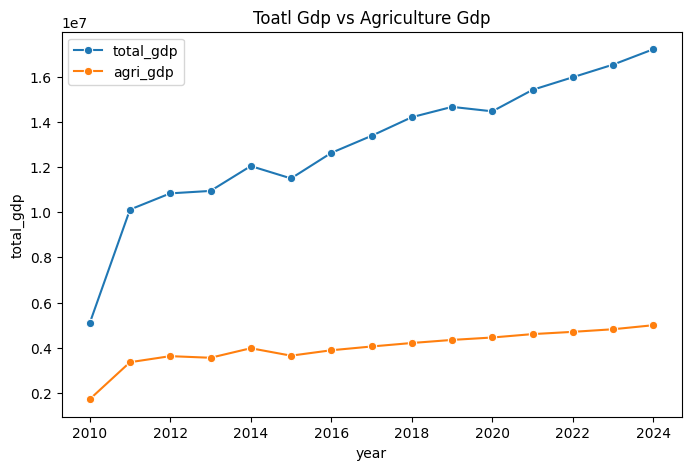

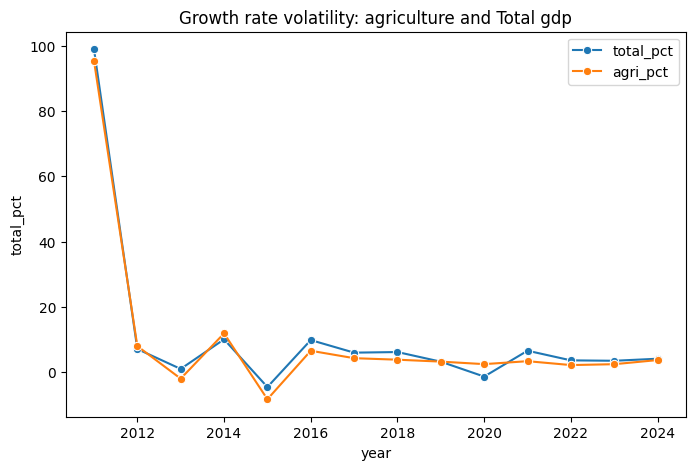

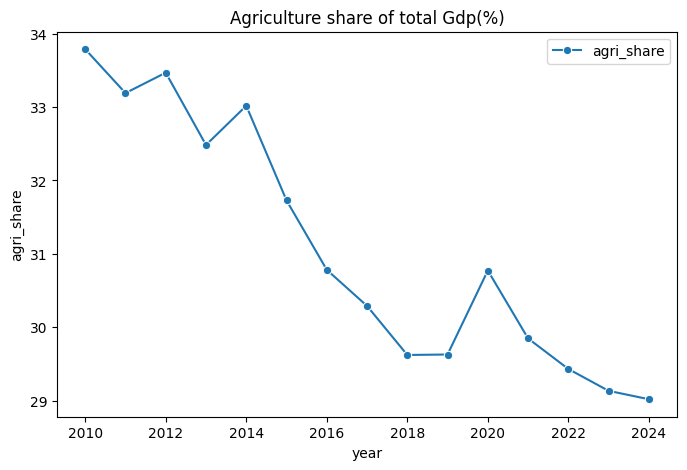

np.int64(0)

In [65]:
#Is agriculture’s share decreasing while total GDP increases?
query = """SELECT 
	sector,
	year_adjusted as year,
	sum(value) as sector_gdp
FROM gdp_data
GROUP BY sector,year_adjusted
order by year_adjusted Asc
"""
data = pd.read_sql(query,engine)
data.dropna(inplace = True)
agri_data = data[data["sector"]=="Agriculture, forestry and fishing"]
agri_data = agri_data.rename(columns = {"sector_gdp":"agri_gdp"})

data= data.groupby("year")["sector_gdp"].sum().reset_index()
data = data.rename(columns = {"sector_gdp":"total_gdp"})

#merging two dataframe
data = data.merge(agri_data,on="year")

data["agri_share"] = (data["agri_gdp"]/data["total_gdp"])*100

data["total_pct"] = data["total_gdp"].pct_change()*100
data["agri_pct"] = data["agri_gdp"].pct_change()*100

plt.figure(figsize=(8,5))
sns.lineplot(x="year",y="total_gdp",marker="o",data=data,label="total_gdp")
sns.lineplot(x="year",y="agri_gdp",marker="o",data=data,label="agri_gdp")
plt.title("Toatl Gdp vs Agriculture Gdp")
plt.legend()
plt.show()
# insight: Both total GDP and agriculture GDP show an upward trend over time, indicating overall economic expansion. 
#However, total GDP grows at a faster pace compared to agriculture.

# How volatile is agriculture compared to total GDP?
plt.figure(figsize=(8,5))
sns.lineplot(x="year",y="total_pct",marker="o",data=data,label="total_pct")
sns.lineplot(x="year",y="agri_pct",marker="o",data=data,label="agri_pct")
plt.title("Growth rate volatility: agriculture and Total gdp")
plt.legend()
plt.show()
#insight: Agriculture growth is more volatile compared to total GDP growth. Sharp fluctuations in agricultural output 
#are often reflected in total GDP growth, suggesting that agriculture still plays a significant role in short-term economic performance.

plt.figure(figsize=(8,5))
sns.lineplot(x="year",y="agri_share",marker="o",data=data,label="agri_share")
plt.title("Agriculture share of total Gdp(%)")
plt.legend()
plt.show()
# insight: Despite growth in agriculture GDP, its share of total GDP shows a declining trend over time. 
#This indicates that other sectors (likely services and industry) are growing faster than agriculture.

data[["total_pct","agri_pct"]].corr()

#how much contrubution to gdp in 2024
agri_2024=agri_data[agri_data['year']==2024]
total_2024 = data[data['year']==2024]
share = (agri_2024['agri_gdp'].iloc[0]/total_2024['total_gdp'].iloc[0])*100
share
#answer: 29%

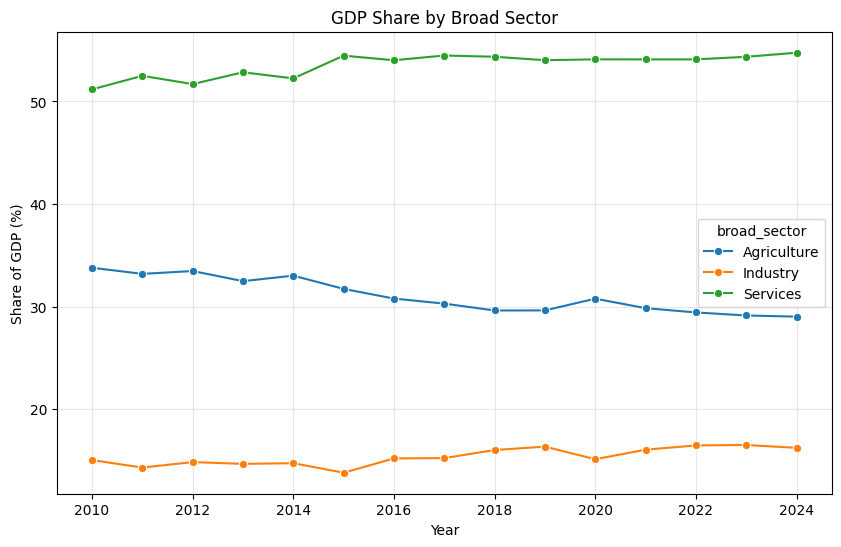

year               2010       2024    change
broad_sector                                
Services      51.177891  54.754571  3.576681
Industry      15.033980  16.226301  1.192321
Agriculture   33.788130  29.019128 -4.769002


In [8]:
#Which sector is replacing agriculture?
query = """SELECT 
	sector,
	year_adjusted as year,
	sum(value) as sector_gdp
FROM gdp_data
GROUP BY sector,year_adjusted
order by year_adjusted Asc
"""
data = pd.read_sql(query,engine)
data = data[data["year"] != 2025]

industry = [
    "Manufacturing",
    "Construction",
    "Electricity, gas, steam and air conditioning supply",
    "Water supply; sewerage, waste management ",
    "Mining and quarrying"
]

data["broad_sector"] = "Services"

data.loc[
    data["sector"] == "Agriculture, forestry and fishing",
    "broad_sector"
] = "Agriculture"

data.loc[
    data["sector"].isin(industry),
    "broad_sector"
] = "Industry"

sector_gdp = (
    data.groupby(["year", "broad_sector"])["sector_gdp"]
    .sum()
    .reset_index()
)
total_gdp = (
    sector_gdp.groupby("year")["sector_gdp"]
    .sum()
    .reset_index(name="total_gdp")
)

sector_gdp = sector_gdp.merge(total_gdp, on="year")

sector_gdp["share"] = (
    sector_gdp["sector_gdp"]
    / sector_gdp["total_gdp"]
) * 100
plt.figure(figsize=(10,6))

sns.lineplot(
    data=sector_gdp,
    x="year",
    y="share",
    hue="broad_sector",
    marker="o"
)

plt.title("GDP Share by Broad Sector")
plt.xlabel("Year")
plt.ylabel("Share of GDP (%)")
plt.grid(alpha=0.3)

plt.show()
pivot = sector_gdp.pivot(
    index="broad_sector",
    columns="year",
    values="share"
)

first_year = pivot.columns.min()
last_year = pivot.columns.max()

pivot["change"] = pivot[last_year] - pivot[first_year]

print(
    pivot[[first_year, last_year, "change"]]
    .sort_values("change", ascending=False)
)


<class 'pandas.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   unnamed:_0     1120 non-null   int64         
 1   year           1120 non-null   datetime64[us]
 2   category       1120 non-null   str           
 3   production     1120 non-null   float64       
 4   growth_rate    1120 non-null   float64       
 5   main_category  1120 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 52.6 KB


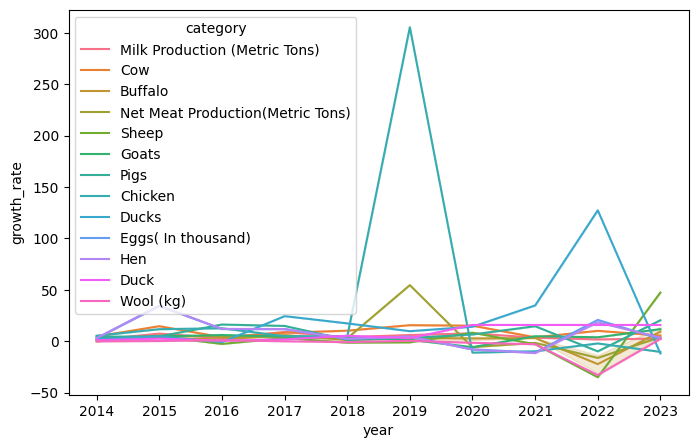

,unnamed:_0,year,category,production,growth_rate,main_category
3,3,2017-01-01,Milk Production (Metric Tons),2085000.0,9.091537,Milk
143,3,2017-01-01,Milk Production (Metric Tons),2085000.0,9.091537,Milk
423,3,2017-01-01,Milk Production (Metric Tons),2085000.0,9.091537,Milk
283,3,2017-01-01,Milk Production (Metric Tons),2085000.0,9.091537,Milk
843,3,2017-01-01,Milk Production (Metric Tons),2085000.0,9.091537,Milk
...,...,...,...,...,...,...
513,93,2017-01-01,Ducks,300.0,24.481328,Livestock
793,93,2017-01-01,Ducks,300.0,24.481328,Livestock
653,93,2017-01-01,Ducks,300.0,24.481328,Livestock
933,93,2017-01-01,Ducks,300.0,24.481328,Livestock


In [67]:
#Q5. How has livestock production changed over time?
query = """SELECT * FROM livestock_production"""
data = pd.read_sql(query,engine)
data

data["year"] = pd.to_datetime(data["year"])
data.info()
plt.figure(figsize=(8,5))
# sns.lineplot(x="year",y="production",data=data)
sns.lineplot(x="year",y="growth_rate",data=data,hue='category')
plt.show()
data
grouped_data = data[data['year'] == '2017']
grouped_data.groupby('category')['production'].sum()
grouped_data.sort_values(by='production',ascending=False)
#insights: key driver is chicken and ducks where growth rate is high although the production of milk is high 

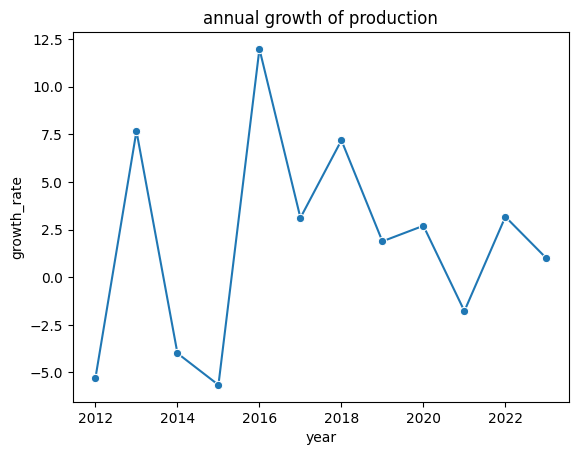

In [47]:
#Q6.What is the annual growth rate of total agriculture production?
query = """WITH yearly_production AS (
    SELECT
        year,
        SUM(value) AS total_production
    FROM agriculture_production
    WHERE type = 'Production'
    GROUP BY year
),
growth AS (
    SELECT
        year,
        total_production,
        ((total_production - LAG(total_production) OVER (ORDER BY year))
        / LAG(total_production) OVER (ORDER BY year)) * 100 AS growth_rate
    FROM yearly_production
)
SELECT *
FROM growth
ORDER BY year;
"""
data = pd.read_sql(query,engine)
sns.lineplot(x='year',y='growth_rate',data=data,marker='o')
plt.title('annual growth of production')
plt.show()

In [42]:
#In which years did agriculture experience highest and lowest growth?
query = """WITH yearly_production AS (
    SELECT
        year,
        SUM(value) AS total_production
    FROM agriculture_production
    WHERE type = 'Production'
    GROUP BY year
),
growth AS (
    SELECT
        year,
        total_production,
        ((total_production - LAG(total_production) OVER (ORDER BY year))
        / LAG(total_production) OVER (ORDER BY year)) * 100 AS growth_rate
    FROM yearly_production
)
SELECT *
FROM growth
ORDER BY year;
"""
data = pd.read_sql(query,engine)

highest = data.loc[data['growth_rate'].idxmax()]
lowest = data.loc[data['growth_rate'].idxmin()]

print("Highest Growth Year")
print(highest)

print("\nLowest Growth Year")
print(lowest)
data


Highest Growth Year
year                  2016.00000
total_production    127435.35310
growth_rate             11.98026
Name: 5, dtype: float64

Lowest Growth Year
year                  2015.000000
total_production    113801.622500
growth_rate             -5.654025
Name: 4, dtype: float64


,year,total_production,growth_rate
0,2011,123200.000000,NaN
1,2012,116690.500000,-5.283685
2,2013,125638.570000,7.668208
3,2014,120621.597600,-3.993179
4,2015,113801.622500,-5.654025
5,2016,127435.353100,11.980260
6,2017,131404.730000,3.114816
7,2018,140847.075240,7.185697
8,2019,143496.134159,1.880805
9,2020,147368.433069,2.698539


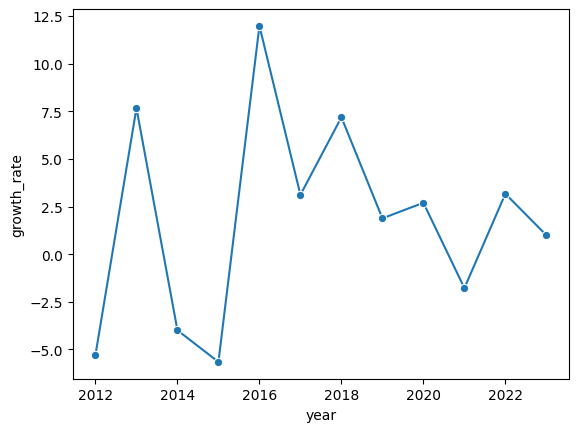

In [45]:
#Are agriculture growth trends consistent or fluctuating?
#In which years did agriculture experience highest and lowest growth?
query = """WITH yearly_production AS (
    SELECT
        year,
        SUM(value) AS total_production
    FROM agriculture_production
    WHERE type = 'Production'
    GROUP BY year
),
growth AS (
    SELECT
        year,
        total_production,
        ((total_production - LAG(total_production) OVER (ORDER BY year))
        / LAG(total_production) OVER (ORDER BY year)) * 100 AS growth_rate
    FROM yearly_production
)
SELECT *
FROM growth
ORDER BY year;
"""
data = pd.read_sql(query,engine)
sns.lineplot(x='year',y='growth_rate',data=data,marker='o')
plt.show()
#insights : this graph suggest agriculture production is not stable or consistent

In [5]:
#What is absolute MT production in 2011 vs 2023? (anchor numbers)
query = """WITH BASE AS (
SELECT
    crop_type,
    crop,
    year,
    MAX(CASE WHEN type = 'Area' THEN value END) AS area,
    MAX(CASE WHEN type = 'Production' THEN value END) AS production,
    MAX(CASE WHEN type = 'Productivity' THEN value END) AS productivity
  FROM agriculture_production
  GROUP BY crop_type, crop, year
)
SELECT YEAR,SUM(PRODUCTION) FROM BASE
WHERE crop_type = 'cash'
GROUP BY YEAR
ORDER BY YEAR"""
data = pd.read_sql(query,engine)
data
#insights: --IN 2011: 11120.51 AND 2023: 11293.84 CASH
          #--IN 2011: 3616.33 AND 2023: 3788.72  FOOD



,year,sum
0,2011,2863.000000
1,2012,2932.000000
2,2013,3001.510000
3,2014,2795.919760
4,2015,2768.875250
5,2016,2974.611310
6,2017,3135.050000
7,2018,3403.138546
8,2019,3417.745050
9,2020,3620.392180


In [23]:
#What % of growth came from area expansion vs yield improvement? (decomposition)
# Formula: ΔProd = (ΔArea × old_yield) + (Δyield × old_area) + (ΔArea × Δyield)
query = """ WITH BASE AS (
  SELECT 
    year,
	crop,
	crop_type,
    MAX(CASE WHEN type = 'Area' THEN value END) AS Area,
	MAX(CASE WHEN type = 'Production' THEN value END) AS Production,
	MAX(CASE WHEN type = 'Productivity' THEN value END) AS Productivity,
    MAX(CASE WHEN type='Production' THEN value END) / NULLIF(MAX(CASE WHEN type='Area' THEN value END),0) AS yield
FROM agriculture_production
GROUP BY year,crop,crop_type
),
PREV_CAL AS (
  SELECT 
    year,
	crop,
	crop_type,
	Area,
    Production,
    Productivity,
    yield,
    LAG(Area) OVER(PARTITION BY crop_type,crop ORDER BY year) as prev_area,
    LAG(Production) OVER(PARTITION BY crop_type,crop ORDER BY year) as prev_prod,
    LAG(yield) OVER(PARTITION BY crop_type,crop ORDER BY year) as prev_yield
FROM BASE
)
SELECT 
    year,
    crop,
    crop_type,
    Area,
    Production,
    Productivity,
    prev_area,
    prev_prod,
    prev_yield,
    (Area - prev_area) AS delta_area,
	(Production - prev_prod) AS delta_production,
	(yield - prev_yield) AS delta_yield
FROM PREV_CAL 
ORDER BY year
"""
data = pd.read_sql(query,engine)
data.isnull().sum()
data = data.dropna(
    subset=['prev_area', 'prev_yield', 'prev_prod']
)
data.head(30)

data['Area Effect'] = data['delta_area'] * data['prev_yield']
data['Yield Effect'] = data['delta_yield'] * data['prev_area']
data['Interaction Effect'] = data['delta_area'] * data['delta_yield']


summary = data.groupby(["year","crop_type"],as_index=False)[["Area Effect","Yield Effect","Interaction Effect"]].sum()

summary['Production Change'] = summary['Area Effect'] + summary['Yield Effect'] + summary['Interaction Effect']
summary['Area %'] = summary['Area Effect']/summary['Production Change'] * 100
summary['yield %'] = summary['Yield Effect']/summary['Production Change'] * 100
summary['Interaction %'] = summary['Interaction Effect']/summary['Production Change'] * 100
summary

,year,crop_type,Area Effect,Yield Effect,Interaction Effect,Production Change,Area %,yield %,Interaction %
0,2012,cash,11.851420,56.854057,0.294522,69.000000,17.175971,82.397185,0.426844
1,2012,food,-439.254197,-299.249483,18.553680,-719.950000,61.011764,41.565315,-2.577079
2,2013,cash,260.650475,-174.370828,-16.769647,69.510000,374.982700,-250.857183,-24.125518
3,2013,food,382.997050,419.244483,23.055467,825.297000,46.407178,50.799225,2.793596
4,2014,cash,-104.760282,-106.598665,5.768707,-205.590240,50.955863,51.850061,-2.805925
5,2014,food,-305.091580,4.891278,4.093302,-296.107000,103.034234,-1.651862,-1.382373
6,2015,cash,-79.653073,48.087732,-1.479169,-33.044510,241.047826,-145.524117,4.476292
7,2015,food,-231.314670,-438.428508,17.790178,-651.953000,35.480268,67.248484,-2.728752
8,2016,cash,152.841452,48.979775,2.914832,204.736060,74.652922,23.923375,1.423702
9,2016,food,662.146900,455.537836,40.452264,1158.137000,57.173452,39.333674,3.492874


In [8]:
#Which specific crops drove overall growth — and which dragged it down?
# Group by crop, compute CAGR per crop, rank top 3 and bottom 3.
query = """WITH ranked AS (
SELECT
  crop,
  year,
  value,
  ROW_NUMBER() OVER(PARTITION BY crop ORDER BY year) AS first_row,
  ROW_NUMBER() OVER(PARTITION BY crop ORDER BY year DESC) AS last_row
FROM agriculture_production
where type = 'Production'

)
SELECT
    crop,
    MAX(CASE WHEN first_row = 1 THEN year END) AS first_year,
    MAX(CASE WHEN first_row = 1 THEN value END) AS first_production,
    MAX(CASE WHEN last_row = 1 THEN year END) AS last_year,
    MAX(CASE WHEN last_row = 1 THEN value END) AS last_production
FROM ranked
GROUP BY crop
"""
data = pd.read_sql(query,engine)
n=data['last_year'] - data['first_year']
data['crop'] = data['crop'].str.strip('*')
data['CAGR'] = np.where(data['first_production']>0,(data['last_production']/data['first_production'])**(1/n)-1,np.nan)
data["CAGR (%)"] = data["CAGR"] * 100
data_top3 = data.sort_values(by='CAGR',ascending=False)
data_last3 = data.sort_values(by='CAGR')
data['production_change'] = (data["last_production"]-data['first_production'])
data.sort_values(by='production_change',ascending=False)

,crop,first_year,first_production,last_year,last_production,CAGR,CAGR (%),production_change
3,maize,2011,2179.0,2023,3193.87,0.032377,3.237703,1014.87
7,potato,2011,2682.0,2023,3521.79,0.022960,2.296017,839.79
6,paddy,2011,5072.0,2023,5724.23,0.010132,1.013205,652.23
8,wheat,2011,1846.0,2023,2035.56,0.008179,0.817909,189.56
5,oilseeds,2011,181.0,2023,262.56,0.031484,3.148401,81.56
1,buck wheat,2011,10.0,2023,14.52,0.031566,3.156647,4.52
2,honey,2011,0.0,2023,4.37,NaN,NaN,4.37
0,barley,2011,35.0,2023,24.93,-0.027877,-2.787707,-10.07
4,millet,2011,315.0,2023,300.73,-0.003856,-0.385586,-14.27


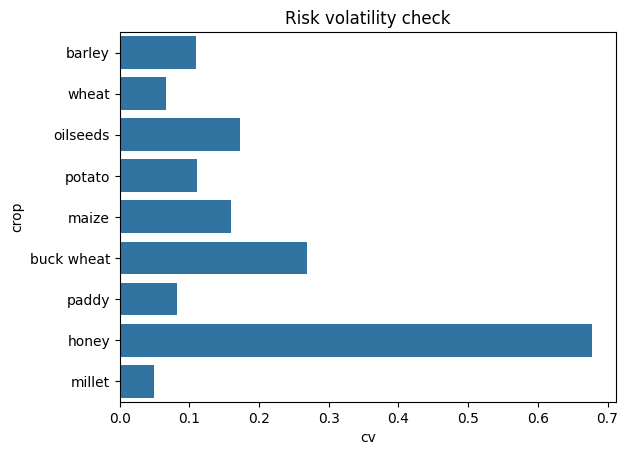

,crop,std_production,average_production,cv
0,barley,59.218978,541.809873,0.109298
1,wheat,2217.049097,33641.152425,0.065903
2,oilseeds,699.387135,4041.208505,0.173064
3,potato,5660.198484,51003.312128,0.110977
4,maize,7059.712368,44164.434909,0.159851
5,buck wheat,60.062893,223.401180,0.268857
6,paddy,7193.657669,87899.027957,0.081840
7,honey,31.080393,45.843361,0.677969
8,millet,262.372588,5378.722761,0.048780


In [3]:
#What is the Coefficient of Variation (CV) of production? (quantifies volatility)
#CV = std/mean on annual production. CV > 0.5 = high risk.
query = """WITH AGGREGRATION AS (
SELECT
    year,
	crop,
    SUM(value) as production
FROM agriculture_production
WHERE type = 'Production'
GROUP BY crop,year
)
SELECT 
	crop,
	STDDEV_POP(production) as std_production,
	AVG(production) as average_production,
	(STDDEV_POP(production)/AVG(production)) as cv
FROM AGGREGRATION
GROUP BY crop
"""
data = pd.read_sql(query,engine)
data['crop']=data['crop'].str.replace('*','')
sns.barplot(x='cv',y='crop',data=data)
plt.title("Risk volatility check")
plt.show()
data

In [16]:
# --CAGR of total production 2011–2023
# --CAGR = (end/start)^(1/n) - 1. Apply to production, area, productivity separately.
query = """WITH ranked AS (
SELECT
  crop,
  type,
  year,
  value,
  ROW_NUMBER() OVER(PARTITION BY crop,type ORDER BY year) AS first_row,
  ROW_NUMBER() OVER(PARTITION BY crop,type ORDER BY year DESC) AS last_row
FROM agriculture_production
)
SELECT
    crop,
    type,
    MAX(CASE WHEN first_row = 1 THEN year END) AS first_year,
    MAX(CASE WHEN first_row = 1 THEN value END) AS first_production,
    MAX(CASE WHEN last_row = 1 THEN year END) AS last_year,
    MAX(CASE WHEN last_row = 1 THEN value END) AS last_production
FROM ranked
GROUP BY crop,type;
"""
data = pd.read_sql(query,engine)
n=data['last_year'] - data['first_year']
data['CAGR'] = np.where(data['first_production']>0,(data['last_production']/data['first_production'])**(1/n)-1,np.nan)
data["CAGR (%)"] = data["CAGR"] * 100
data

,crop,type,first_year,first_production,last_year,last_production,CAGR,CAGR (%)
0,barley,Area,2011,27.300000,2023,18.600,-0.031471,-3.147123
1,barley,Production,2011,35.000000,2023,24.930,-0.027877,-2.787707
2,barley,Productivity,2011,1.250000,2023,1.340,0.005811,0.581066
3,buck wheat*,Area,2011,10.300000,2023,11.250,0.007379,0.737911
4,buck wheat*,Production,2011,10.000000,2023,14.520,0.031566,3.156647
5,buck wheat*,Productivity,2011,0.970000,2023,1.290,0.024043,2.404293
6,honey*,Bee Hives (Number),2011,0.000000,2023,250.500,NaN,NaN
7,honey*,Production,2011,0.000000,2023,4.370,NaN,NaN
8,honey*,Productivity,2011,0.000000,2023,0.017,NaN,NaN
9,maize,Area,2011,871.000000,2023,916.040,0.004210,0.421034
